Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('india_job_market_2024_2026.csv')

In [3]:
df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   object 
 1   Job_Title           5000 non-null   object 
 2   Company             5000 non-null   object 
 3   Company_Type        5000 non-null   object 
 4   Industry            5000 non-null   object 
 5   City                5000 non-null   object 
 6   Location_Tier       5000 non-null   object 
 7   Experience_Level    5000 non-null   object 
 8   Job_Type            5000 non-null   object 
 9   Work_Mode           5000 non-null   object 
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   object 
 12  Education_Required  5000 non-null   object 
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_P

Null Values

In [5]:
df.isnull().sum()

Job_ID                0
Job_Title             0
Company               0
Company_Type          0
Industry              0
City                  0
Location_Tier         0
Experience_Level      0
Job_Type              0
Work_Mode             0
Salary_LPA            0
Skills_Required       0
Education_Required    0
Openings              0
Applicants            0
Company_Rating        0
Date_Posted           0
dtype: int64

In [6]:
df.describe()

,Salary_LPA,Openings,Applicants,Company_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.829440,3.642600,302.072000,3.698420
std,18.136741,4.046942,363.989613,0.424994
min,0.800000,1.000000,14.000000,2.500000
25%,6.800000,1.000000,99.000000,3.400000
50%,13.600000,2.000000,185.000000,3.800000
75%,25.600000,3.000000,321.000000,4.100000
max,115.400000,20.000000,2387.000000,4.300000


Duplicates

In [7]:
df.duplicated().sum()

0

In [8]:
df.dtypes

Job_ID                 object
Job_Title              object
Company                object
Company_Type           object
Industry               object
City                   object
Location_Tier          object
Experience_Level       object
Job_Type               object
Work_Mode              object
Salary_LPA            float64
Skills_Required        object
Education_Required     object
Openings                int64
Applicants              int64
Company_Rating        float64
Date_Posted            object
dtype: object

In [9]:
df.columns

Index(['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings',
       'Applicants', 'Company_Rating', 'Date_Posted'],
      dtype='object')

Conversions - Salary, Experience, Dates

In [10]:
df['Salary_LPA'] = df['Salary_LPA'].replace('[\$,]', '', regex=True).astype(float)

In [11]:
import re

def convert_experience(exp):
    range_match = re.search(r'(\d+)-(\d+)', exp)

    if range_match:
        low = float(range_match.group(1))
        high = float(range_match.group(2))
        return (low + high) / 2

    plus_match = re.search(r'(\d+)\+', exp)
    if plus_match:
        return float(plus_match.group(1))
    return np.nan

In [12]:
df['Experience_Years'] = df['Experience_Level'].apply(convert_experience)

In [13]:
df['Experience_Level'].unique()

array(['Senior (6-10 yrs)', 'Mid (3-6 yrs)', 'Junior (1-3 yrs)',
       'Fresher (0-1 yr)', 'Lead (10+ yrs)'], dtype=object)

In [14]:
df['Experience_Years'].unique()

array([ 8. ,  4.5,  2. ,  0.5, 10. ])

In [15]:
df['Salary_LPA'].astype(float)

0       30.9
1       58.6
2       18.4
3       21.7
4        8.0
        ... 
4995     4.5
4996     4.3
4997    10.5
4998     1.6
4999    25.2
Name: Salary_LPA, Length: 5000, dtype: float64

In [16]:
df['Openings'].astype(int)
df['Applicants'].astype(int)
df['Company_Rating'].astype(float)

0       4.0
1       4.0
2       3.6
3       3.5
4       3.9
       ... 
4995    4.2
4996    4.0
4997    3.1
4998    3.9
4999    4.3
Name: Company_Rating, Length: 5000, dtype: float64

In [17]:
df.dtypes

Job_ID                 object
Job_Title              object
Company                object
Company_Type           object
Industry               object
City                   object
Location_Tier          object
Experience_Level       object
Job_Type               object
Work_Mode              object
Salary_LPA            float64
Skills_Required        object
Education_Required     object
Openings                int64
Applicants              int64
Company_Rating        float64
Date_Posted            object
Experience_Years      float64
dtype: object

In [18]:
df['Date_Posted'].unique()

array(['2025-10-31', '2025-05-19', '2024-08-21', '2026-03-18',
       '2024-10-25', '2026-04-28', '2024-06-04', '2024-06-20',
       '2025-02-27', '2026-01-24', '2026-04-06', '2024-08-17',
       '2025-12-22', '2024-08-10', '2024-10-13', '2024-11-09',
       '2025-03-06', '2024-09-23', '2025-12-26', '2025-06-27',
       '2025-12-02', '2025-12-04', '2024-12-14', '2025-03-18',
       '2025-10-20', '2025-12-25', '2024-08-19', '2026-01-20',
       '2025-10-11', '2025-09-09', '2024-12-22', '2025-04-16',
       '2024-08-28', '2025-07-22', '2025-03-05', '2024-12-01',
       '2024-08-06', '2025-08-28', '2025-09-25', '2024-08-13',
       '2026-02-09', '2025-07-24', '2024-12-10', '2025-12-18',
       '2025-03-10', '2024-12-11', '2024-09-11', '2025-10-13',
       '2025-08-16', '2026-04-25', '2025-07-11', '2025-04-13',
       '2025-09-23', '2025-09-26', '2025-07-03', '2024-09-10',
       '2024-10-07', '2024-06-27', '2026-02-20', '2024-08-07',
       '2025-05-14', '2025-12-28', '2025-03-13', '2026-

In [19]:
df['Date_Posted'] = pd.to_datetime(df['Date_Posted'])

In [20]:
df.columns

Index(['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings',
       'Applicants', 'Company_Rating', 'Date_Posted', 'Experience_Years'],
      dtype='object')

In [21]:
df.dtypes

Job_ID                        object
Job_Title                     object
Company                       object
Company_Type                  object
Industry                      object
City                          object
Location_Tier                 object
Experience_Level              object
Job_Type                      object
Work_Mode                     object
Salary_LPA                   float64
Skills_Required               object
Education_Required            object
Openings                       int64
Applicants                     int64
Company_Rating               float64
Date_Posted           datetime64[ns]
Experience_Years             float64
dtype: object

Type conversions - list

In [22]:
df['Skills_Required'].unique()

array(['Kotlin, Java, REST APIs',
       'Selenium, Manual Testing, Postman, API Testing, Python',
       'JIRA, Excel, Power BI', ...,
       'Python, API Testing, Manual Testing, JIRA',
       'Tailwind CSS, Figma, React, JavaScript, TypeScript',
       'ETL, Azure, Power BI'], dtype=object)

In [23]:
df['Skills_List'] = df['Skills_Required'].str.split(', ')

In [24]:
df['Skills_List'].head()

0                            [Kotlin, Java, REST APIs]
1    [Selenium, Manual Testing, Postman, API Testin...
2                              [JIRA, Excel, Power BI]
3    [Penetration Testing, Python, Ethical Hacking,...
4                 [Docker, REST APIs, AWS, PostgreSQL]
Name: Skills_List, dtype: object

In [25]:
df['Education_Required'].unique()

array(['M.Tech/M.E.', 'B.Tech/B.E.', 'MCA', 'BCA', 'MBA', 'B.Sc (CS/IT)',
       'B.Com + Certification', 'PhD'], dtype=object)

In [26]:
df['Education_List'] = df['Education_Required'].str.split(', ')

In [27]:
df['Education_List'].head()

0    [M.Tech/M.E.]
1    [B.Tech/B.E.]
2            [MCA]
3            [BCA]
4            [MCA]
Name: Education_List, dtype: object

In [28]:
df['Job_Title'].unique()

array(['Android Developer', 'QA Engineer', 'Business Analyst',
       'Cybersecurity Analyst', 'Python Developer', 'Backend Developer',
       'Power BI Developer', 'Java Developer', 'Technical Lead',
       'UI/UX Designer', 'Data Analyst', 'Software Engineer',
       'Machine Learning Engineer', 'Data Engineer', 'Node.js Developer',
       'Computer Vision Engineer', 'MLOps Engineer', 'DevOps Engineer',
       'Product Manager', 'Frontend Developer', 'Full Stack Developer',
       'Cloud Engineer', 'React Developer', 'Blockchain Developer',
       'AI Engineer', 'Research Scientist', 'iOS Developer',
       'NLP Engineer', 'Data Scientist', 'Engineering Manager'],
      dtype=object)

In [29]:
df['Job_Title'].value_counts()

Job_Title
Software Engineer            336
Backend Developer            278
Full Stack Developer         260
Data Analyst                 254
Java Developer               249
Python Developer             246
React Developer              224
Data Scientist               218
Business Analyst             198
Frontend Developer           193
DevOps Engineer              192
Data Engineer                183
Android Developer            172
Node.js Developer            169
Machine Learning Engineer    169
Product Manager              163
AI Engineer                  156
Cloud Engineer               143
QA Engineer                  138
Technical Lead               137
UI/UX Designer               125
Power BI Developer           113
MLOps Engineer               110
iOS Developer                104
Cybersecurity Analyst         96
Engineering Manager           85
NLP Engineer                  81
Research Scientist            80
Computer Vision Engineer      76
Blockchain Developer          52


In [30]:
df['Company'].unique()

array(['Tech Mahindra', 'Dream11', 'HAL', 'Groww', 'Oracle', 'Nykaa',
       'PhonePe', 'Cisco', 'HCL Technologies', 'Chargebee', 'Infosys',
       'Hasura', 'ISRO', 'Google', 'BHEL', 'Cognizant', 'BrowserStack',
       'Setu', 'BSNL', 'CRED', "Byju's", 'Lenskart', 'Khatabook', 'Wipro',
       'Razorpay', 'Deloitte', 'Accenture', 'Urban Company', 'Zoho',
       'Leadsquared', 'BEL', 'Flipkart', 'TCS', 'InMobi', 'IBM', 'ONGC',
       'Freshworks', 'MakeMyTrip', 'Ola', 'Capgemini', 'Amazon', 'Paytm',
       'Microsoft', 'Meesho', 'Zerodha', 'Postman', 'Swiggy', 'Fi Money',
       'Slice', 'Zomato', 'DRDO', 'NTPC', 'Darwinbox'], dtype=object)

In [31]:
df['Company'].value_counts()

Company
Wipro               134
TCS                 125
Tech Mahindra       119
Microsoft           119
Oracle              118
Cisco               118
Capgemini           117
Google              116
Accenture           115
Deloitte            112
Urban Company       112
Infosys             109
IBM                 108
Setu                107
HAL                 105
HCL Technologies    105
Cognizant           104
Lenskart            104
Leadsquared         103
BrowserStack        101
Fi Money            101
Hasura               99
Amazon               98
InMobi               97
Dream11              97
Chargebee            91
Razorpay             91
Nykaa                89
Slice                89
Postman              87
Zerodha              87
Groww                86
Zoho                 86
Zomato               85
Khatabook            84
Meesho               82
Swiggy               82
Darwinbox            82
BSNL                 82
ISRO                 82
DRDO                 81
Flipkart

Categorical Conversions

In [32]:
df['Company_Type'].unique()

array(['MNC', 'Indian Unicorn', 'PSU/Govt', 'Startup'], dtype=object)

In [33]:
df['Cat_company_type'] = df['Company_Type'].astype('category')

In [34]:
df['Cat_company_type'].dtypes

CategoricalDtype(categories=['Indian Unicorn', 'MNC', 'PSU/Govt', 'Startup'], ordered=False)

In [35]:
df.dtypes

Job_ID                        object
Job_Title                     object
Company                       object
Company_Type                  object
Industry                      object
City                          object
Location_Tier                 object
Experience_Level              object
Job_Type                      object
Work_Mode                     object
Salary_LPA                   float64
Skills_Required               object
Education_Required            object
Openings                       int64
Applicants                     int64
Company_Rating               float64
Date_Posted           datetime64[ns]
Experience_Years             float64
Skills_List                   object
Education_List                object
Cat_company_type            category
dtype: object

In [36]:
df['Industry'].unique()

array(['Information Technology', 'EdTech', 'Banking & Finance',
       'Media & Entertainment', 'FinTech', 'Government/PSU', 'HealthTech',
       'E-Commerce', 'Logistics', 'Automobile', 'Gaming', 'Telecom',
       'Manufacturing', 'Consulting', 'Retail'], dtype=object)

In [37]:
df['Cat_industry'] = df['Industry'].astype('category')

In [38]:
df['Cat_industry'].dtypes

CategoricalDtype(categories=['Automobile', 'Banking & Finance', 'Consulting',
                  'E-Commerce', 'EdTech', 'FinTech', 'Gaming',
                  'Government/PSU', 'HealthTech', 'Information Technology',
                  'Logistics', 'Manufacturing', 'Media & Entertainment',
                  'Retail', 'Telecom'],
, ordered=False)

In [39]:
df['City'].unique()

array(['Remote', 'Lucknow', 'Mumbai', 'Indore', 'Pune', 'Delhi',
       'Hyderabad', 'Bhubaneswar', 'Bangalore', 'Chennai', 'Kochi',
       'Jaipur', 'Kolkata', 'Coimbatore', 'Chandigarh', 'Ahmedabad',
       'Nagpur'], dtype=object)

In [40]:
df['Location_Tier'].unique()

array(['Remote', 'Tier 2', 'Tier 1'], dtype=object)

In [41]:
df['Cat_location_tier'] = df['Location_Tier'].astype('category')

In [42]:
df['Cat_location_tier'].dtypes

CategoricalDtype(categories=['Remote', 'Tier 1', 'Tier 2'], ordered=False)

In [43]:
df['Job_Type'].unique()

array(['Full-Time', 'Part-Time', 'Internship', 'Contract'], dtype=object)

In [44]:
df['Cat_job_type'] = df['Job_Type'].astype('category')

In [45]:
df['Cat_job_type'].dtypes

CategoricalDtype(categories=['Contract', 'Full-Time', 'Internship', 'Part-Time'], ordered=False)

In [46]:
df['Work_Mode'].unique()
df['Cat_work_mode'] = df['Work_Mode'].astype('category')
df['Cat_work_mode'].dtypes

CategoricalDtype(categories=['Hybrid', 'On-Site', 'Remote'], ordered=False)

In [47]:
df.dtypes

Job_ID                        object
Job_Title                     object
Company                       object
Company_Type                  object
Industry                      object
City                          object
Location_Tier                 object
Experience_Level              object
Job_Type                      object
Work_Mode                     object
Salary_LPA                   float64
Skills_Required               object
Education_Required            object
Openings                       int64
Applicants                     int64
Company_Rating               float64
Date_Posted           datetime64[ns]
Experience_Years             float64
Skills_List                   object
Education_List                object
Cat_company_type            category
Cat_industry                category
Cat_location_tier           category
Cat_job_type                category
Cat_work_mode               category
dtype: object

In [48]:
df.columns

Index(['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings',
       'Applicants', 'Company_Rating', 'Date_Posted', 'Experience_Years',
       'Skills_List', 'Education_List', 'Cat_company_type', 'Cat_industry',
       'Cat_location_tier', 'Cat_job_type', 'Cat_work_mode'],
      dtype='object')

Top Hiring Cities

In [49]:
top_cities = df['City'].value_counts()

In [50]:
filtered_df = df[
    ~df['City'].str.contains('Remote')
]
top_cities = (filtered_df['City'].value_counts())

In [51]:
top_cities.head()

City
Mumbai       372
Pune         371
Hyderabad    359
Bangalore    344
Chennai      322
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_71552\1385552178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index[:10], y=top_cities.values[:10],


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Mumbai'),
  Text(1, 0, 'Pune'),
  Text(2, 0, 'Hyderabad'),
  Text(3, 0, 'Bangalore'),
  Text(4, 0, 'Chennai'),
  Text(5, 0, 'Delhi'),
  Text(6, 0, 'Indore'),
  Text(7, 0, 'Bhubaneswar'),
  Text(8, 0, 'Lucknow'),
  Text(9, 0, 'Jaipur')])

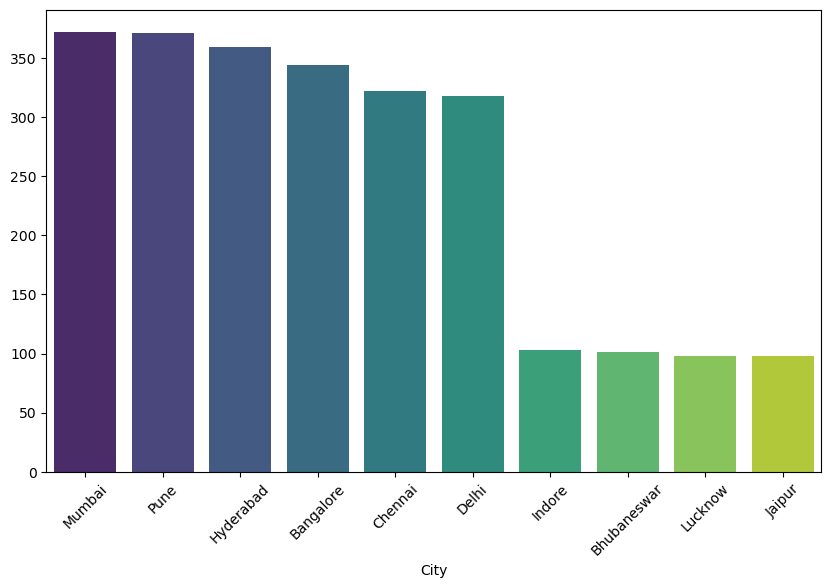

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities.index[:10], y=top_cities.values[:10],
            palette='viridis')
plt.xticks(rotation=45)

Most Demanded Skills

In [53]:
df['Skills_Required'].count()

5000

In [54]:
from collections import Counter

all_skills = []
for skills in df['Skills_List']:
    for skill in skills:
        all_skills.append(skill)

skill_counts = Counter(all_skills)
top_skills = skill_counts.most_common(10)

In [55]:
top_skills[:5]

[('Python', 1579),
 ('REST APIs', 998),
 ('AWS', 867),
 ('SQL', 847),
 ('Docker', 836)]

Text(0, 0.5, 'Skill')

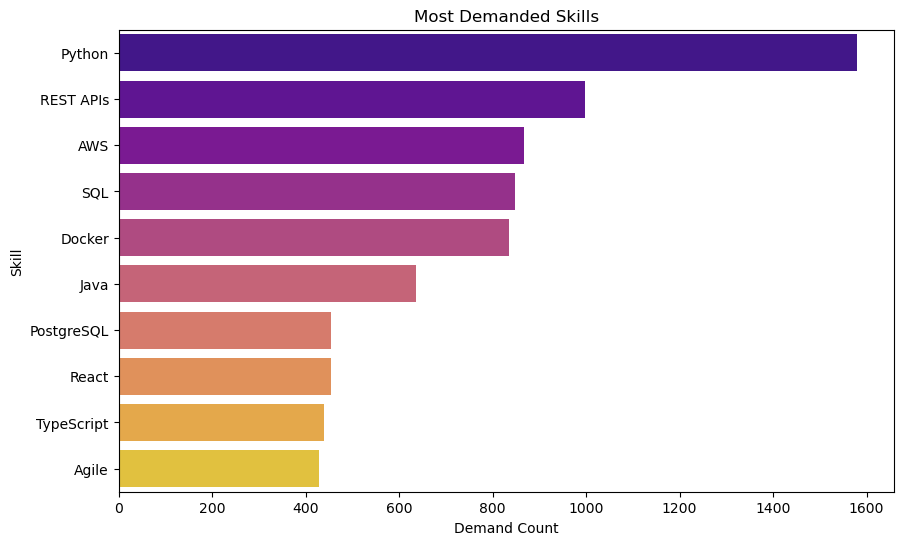

In [56]:
skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Skill',data=skills_df,
            palette='plasma', hue='Skill')
plt.title("Most Demanded Skills")
plt.xlabel("Demand Count")
plt.ylabel("Skill")

Highest Paying Jobs

In [57]:
highest_paying = (
    df.groupby('Job_Title')['Salary_LPA'].mean()
    .sort_values(ascending=False)
)

In [58]:
highest_paying.head()

Job_Title
Research Scientist          26.037500
AI Engineer                 24.858333
Data Scientist              24.258716
Computer Vision Engineer    23.257895
NLP Engineer                22.419753
Name: Salary_LPA, dtype: float64

Text(0, 0.5, 'Job Title')

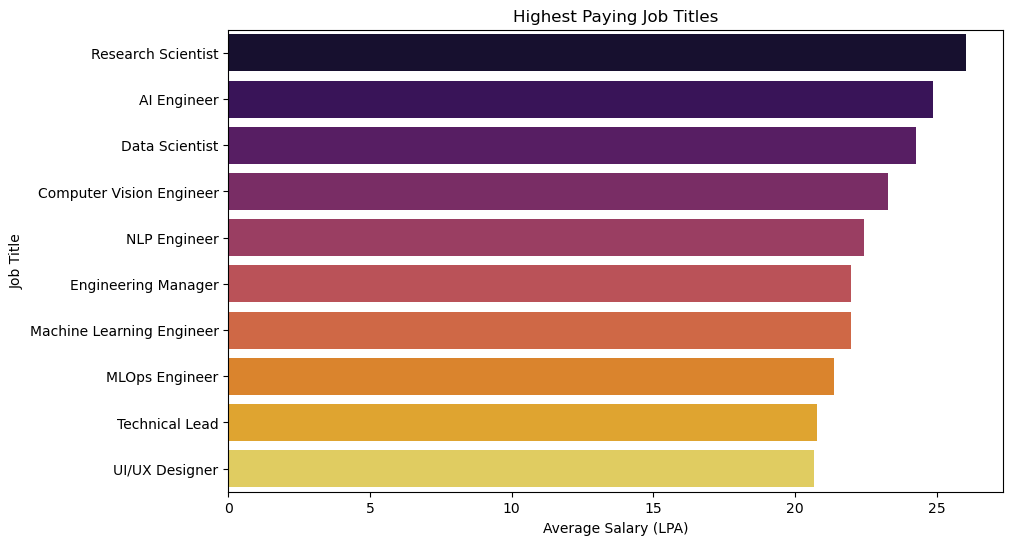

In [59]:
plt.figure(figsize=(10,6))
sns.barplot(x=highest_paying.values[:10], y=highest_paying.index[:10],
            palette='inferno', hue=highest_paying.index[:10])
plt.title("Highest Paying Job Titles")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Job Title")

Hiring Trend - Year

In [60]:
df['Year'] = df['Date_Posted'].dt.year
df['Month'] = df['Date_Posted'].dt.month

In [61]:
hiring_trend = df['Year'].value_counts()

In [62]:
hiring_trend

Year
2025    2629
2024    1522
2026     849
Name: count, dtype: int64

In [63]:
heatmap_data = df.pivot_table(
    index='Month',
    columns='Year',
    values='Job_ID',
    aggfunc='count'
)

Text(120.72222222222221, 0.5, 'Month')

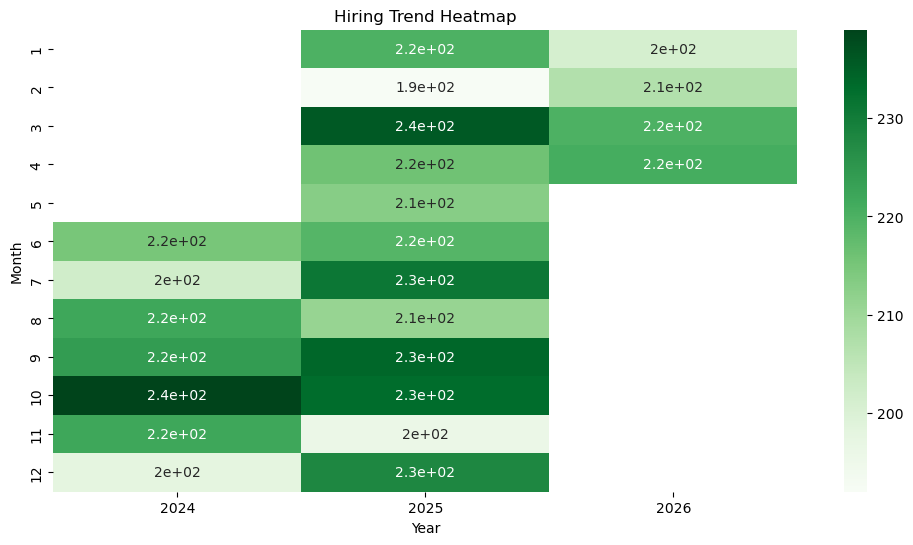

In [64]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True,cmap='Greens')
plt.title("Hiring Trend Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")

Salary Distribution Analysis

Text(0.5, 1.0, 'Salary Distribution')

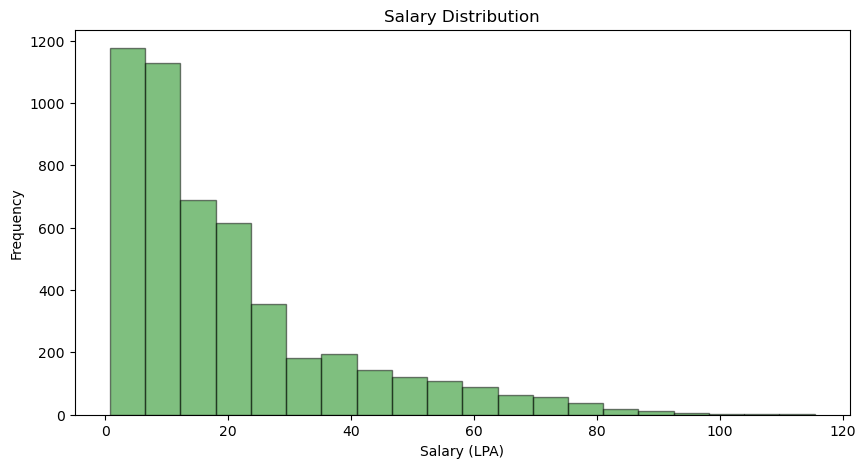

In [65]:
plt.figure(figsize=(10,5))
plt.hist(df['Salary_LPA'], bins=20,
         color='green', edgecolor='black', alpha=0.5, label='Salary')

plt.xlabel("Salary (LPA)")
plt.ylabel("Frequency")
plt.title("Salary Distribution")

Text(0.5, 0, 'Salary (LPA)')

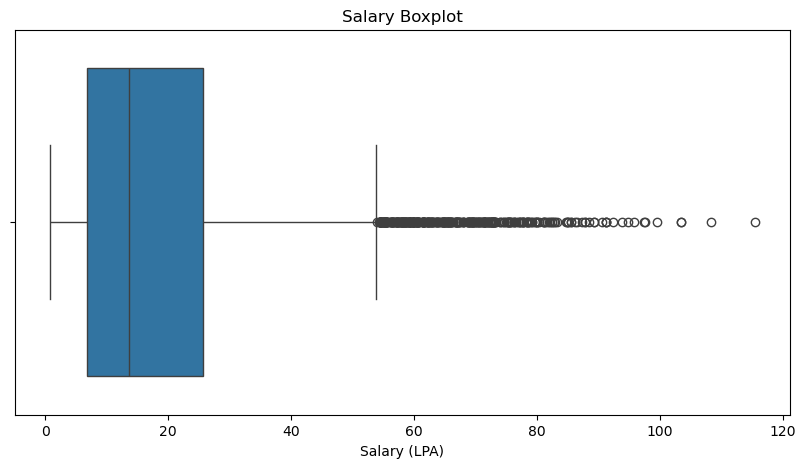

In [66]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Salary_LPA']) #palette='magma', hue=df['Salary_LPA']
plt.title("Salary Boxplot")
plt.xlabel("Salary (LPA)")

Experience - Salary Relationship

Text(0, 0.5, 'Salary (LPA)')

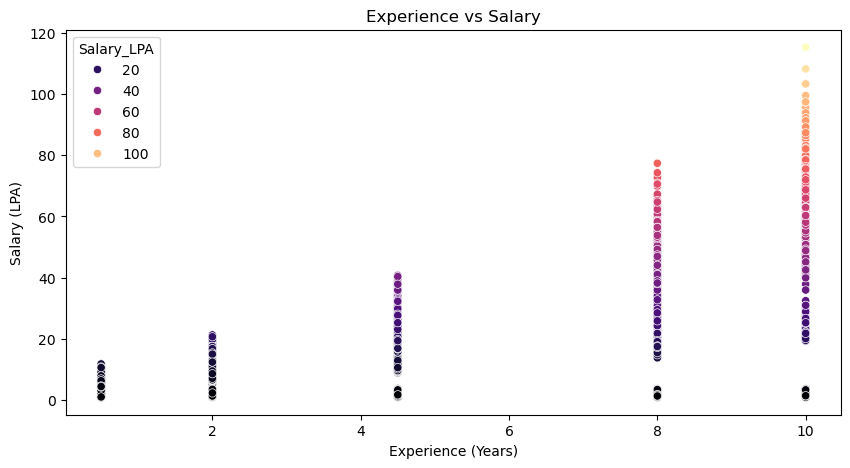

In [67]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Experience_Years', y='Salary_LPA', data=df,
                palette='magma', hue='Salary_LPA')
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (LPA)")

Remote - OnSite Jobs Relationship

Text(0, 0.5, 'Number of Jobs')

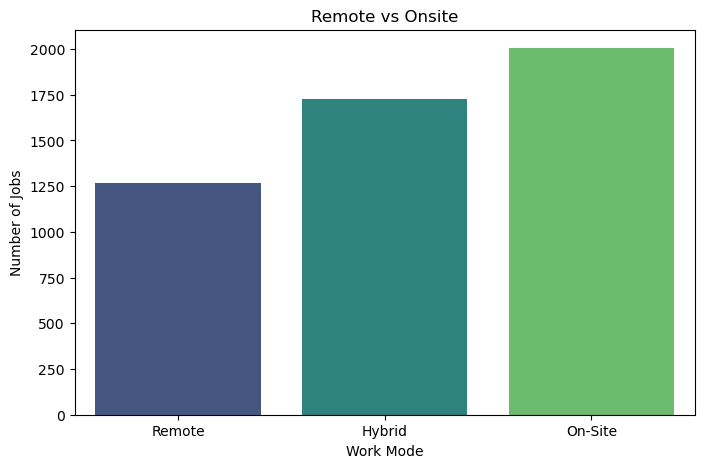

In [68]:
plt.figure(figsize=(8,5))
sns.countplot(x='Work_Mode', data=df,
              palette='viridis', hue='Work_Mode')

plt.title("Remote vs Onsite")
plt.xlabel("Work Mode")
plt.ylabel("Number of Jobs")

Skill Demand - Salary Relationship

In [69]:
skills_salary = df[['Skills_List', 'Salary_LPA']].copy()

skills_salary = skills_salary.explode('Skills_List')
skill_salary = (skills_salary.groupby('Skills_List')['Salary_LPA'].mean()
    .sort_values(ascending=False))

In [70]:
skill_salary.head()

Skills_List
Vector DBs          26.612245
Machine Learning    26.577083
Publications        25.676596
Deep Learning       25.609500
RAG                 25.582927
Name: Salary_LPA, dtype: float64

Text(0, 0.5, 'Skill')

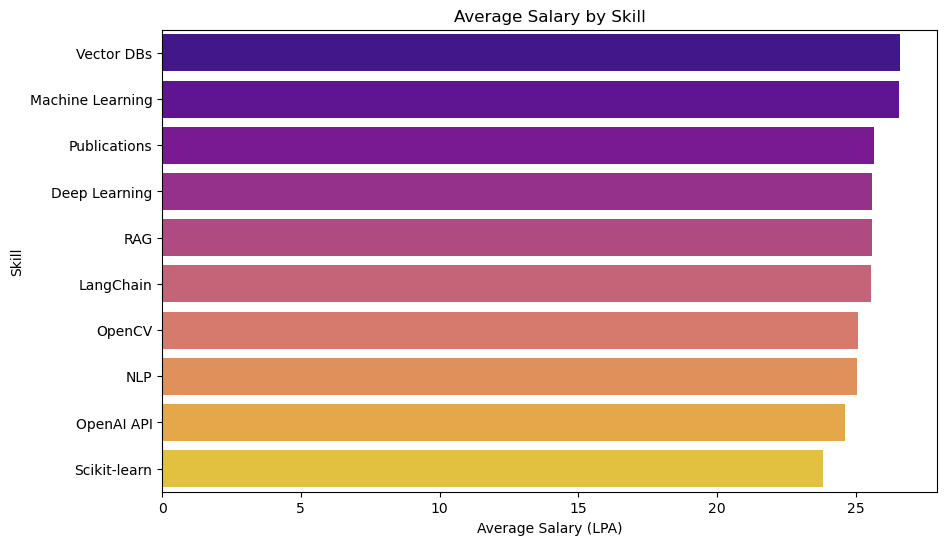

In [71]:
plt.figure(figsize=(10,6))
sns.barplot(x=skill_salary.values[:10], y=skill_salary.index[:10],
            palette='plasma', hue=skill_salary.index[:10])
plt.title("Average Salary by Skill")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Skill")

Pair Plot

C:\Users\Admin\miniconda3\envs\untitled\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1000x600 with 0 Axes>

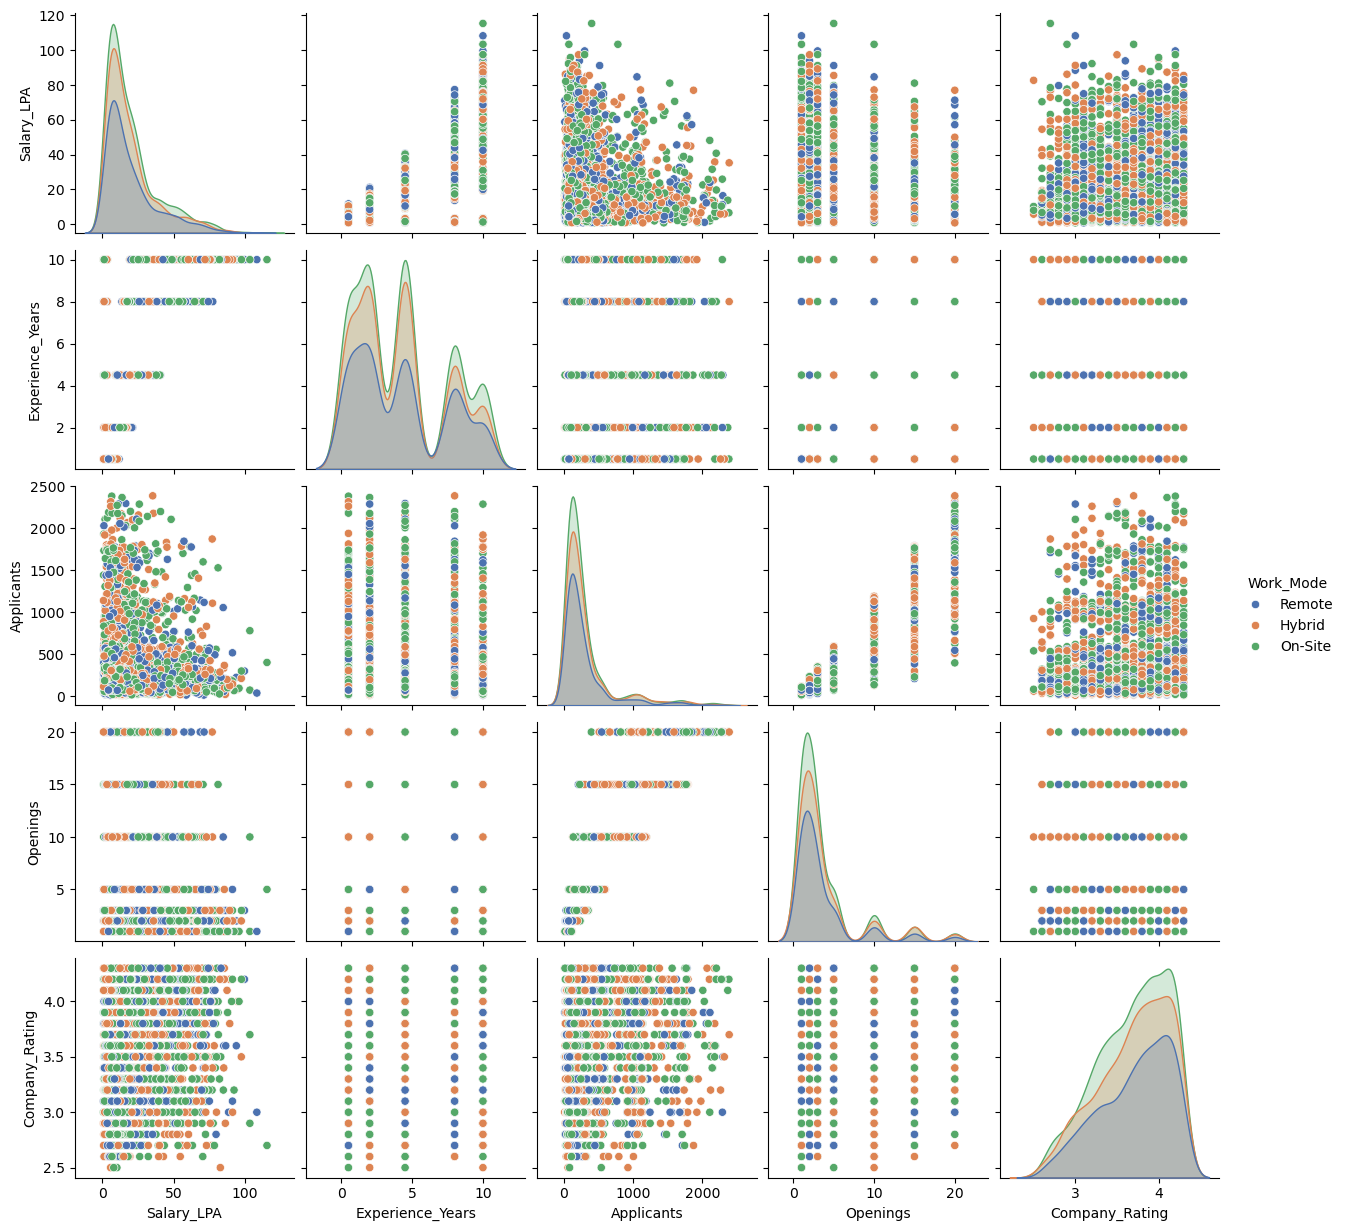

In [72]:
numeric_cols = [
    'Salary_LPA',
    'Experience_Years',
    'Applicants',
    'Openings',
    'Company_Rating'
]
plt.figure(figsize=(10,6))
sns.pairplot(df[numeric_cols + ['Work_Mode']], palette='deep', hue='Work_Mode')

Correlation Matrix

Text(0.5, 1.0, 'Correlation Matrix')

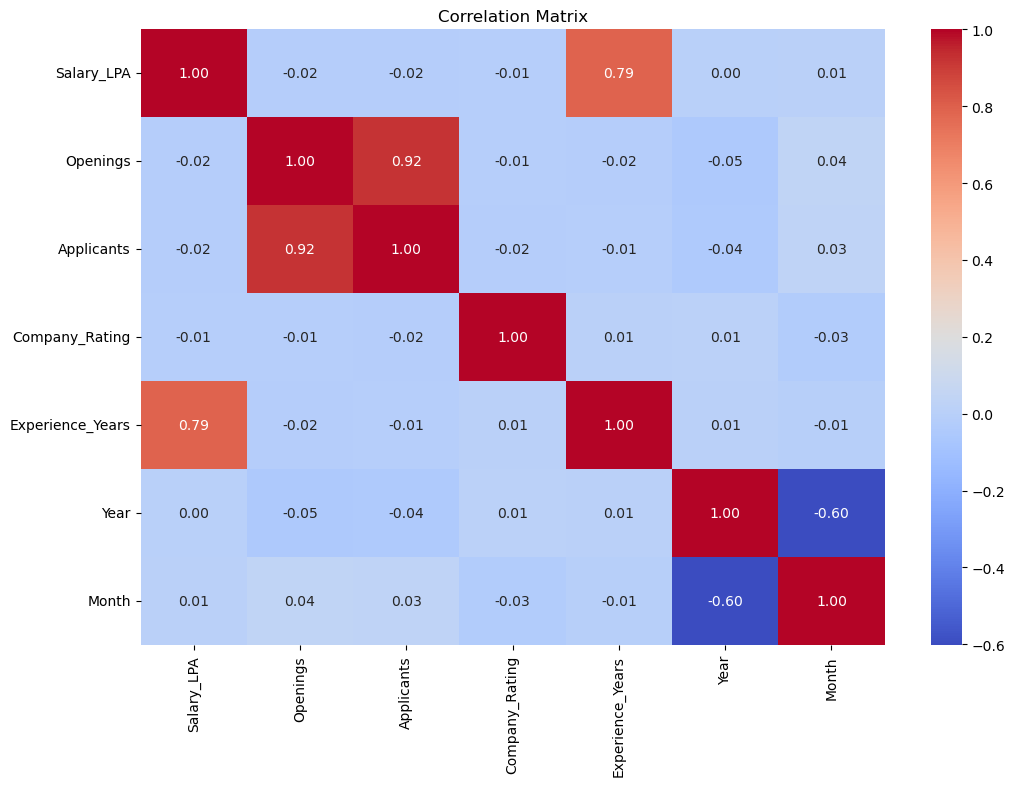

In [73]:
corr_cols = [
    'Salary_LPA',
    'Openings',
    'Applicants',
    'Company_Rating',
    'Experience_Years',
    'Year',
    'Month',
    'Cat_company_type',
    'Cat_industry',
    'Cat_location_tier',
    'Cat_job_type',
    'Cat_work_mode'
]

corr_matrix = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")

Data Statistic OLS Regression

In [74]:
import statsmodels as sm
from statsmodels.formula.api import ols

model = ols('Salary_LPA ~ Experience_Years + Applicants + Openings + Company_Rating', data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Salary_LPA   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     2058.
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        15:46:23   Log-Likelihood:                -19149.
No. Observations:                5000   AIC:                         3.831e+04
Df Residuals:                    4995   BIC:                         3.834e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.2118      1.405      2.285      0.022       0.456       5.967
Experience_Years     4.5485      0.050     90.698      0.000       4.450       4.647
Applicants          -0.0012      0.001     -1.045      0.296      -0.003       0.001
Openings             0.0748      0.100      0.748      0.454      -0.121       0.271
Company_Rating      -0.6514      0.371     -1.755      0.079      -1.379       0.076
==============================================================================
Omnibus:                      630.146   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5190.781
Skew:                          -0.315   Prob(JB):                         0.00
Kurtosis:                       7.952   Cond. No.                     4.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [75]:
df.columns

Index(['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings',
       'Applicants', 'Company_Rating', 'Date_Posted', 'Experience_Years',
       'Skills_List', 'Education_List', 'Cat_company_type', 'Cat_industry',
       'Cat_location_tier', 'Cat_job_type', 'Cat_work_mode', 'Year', 'Month'],
      dtype='object')

Time Series Analysis - ARIMA

In [76]:
from statsmodels.tsa.arima.model import ARIMA

ts_df = df.set_index('Date_Posted')
monthly_hiring = ts_df.resample('M').size()

In [77]:
model = ARIMA(monthly_hiring, order=(1,1,1))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   23
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -89.286
Date:                Fri, 22 May 2026   AIC                            184.572
Time:                        15:46:24   BIC                            187.845
Sample:                    06-30-2024   HQIC                           185.343
                         - 04-30-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2037      0.328     -0.620      0.535      -0.847       0.440
ma.L1         -0.9994     48.663     -0.021      0.984     -96.377      94.378
sigma2       167.1442   8124.406      0.021      0.984   -1.58e+04    1.61e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.07
Prob(Q):                              0.89   Prob(JB):                         0.58
Heteroskedasticity (H):               0.91   Skew:                            -0.32
Prob(H) (two-sided):                  0.91   Kurtosis:                         2.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [82]:
import plotly.express as px

In [83]:
px.box(df, x='Salary_LPA')

In [90]:
px.bar(df, x='Salary_LPA', y='Job_Type', color='Job_Type')

In [100]:
px.treemap(df, path=['Skills_Required'])

In [104]:
px.pie(df, names='Job_Type')

In [105]:
px.scatter(df, x='Salary_LPA', y='Job_Type', color='Job_Type')

In [106]:
px.density_heatmap(df, x='Salary_LPA', y='Job_Type')

In [107]:
city_jobs = (df.groupby('City').size()
    .reset_index(name='Job_Count'))

In [114]:
px.scatter_geo(city_jobs,locations='City',size='Job_Count', locationmode='ISO-3',
    hover_name='City',title='Jobs by City in India')